# Cluster Analysis

This notebook explores county-level agricultural profiles using dimensionality reduction and unsupervised clustering.

Main steps:
- Construct a composite crop productivity indicator
- Aggregate the analytical variables at county level
- Standardize the variables used for clustering
- Apply Principal Component Analysis (PCA) for dimensionality reduction
- Compare alternative clustering specifications and numbers of clusters
- Apply K-means clustering to the retained principal components
- Evaluate cluster quality using silhouette, Calinski-Harabasz, and Davies-Bouldin scores
- Profile and interpret the resulting county clusters
- Visualize cluster profiles and their territorial distribution

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("../../data/processed/analysis_dataset_eurostat.csv")
df.head(2)

,an,judet,emig_masc_nr,emig_fem_nr,emigranti_total_nr,emig_15_64_nr,imig_masc_nr,imig_fem_nr,imigranti_total_nr,imigranti_15_64_nr,...,migratie_neta_15_64_nr,rata_migratie_neta_15_64,ocupati_aff_eurostat_mii,ocupati_total_eurostat_mii,ocupati_aff_eurostat_nr,ocupati_total_eurostat_nr,pondere_ocupati_aff_eurostat,schimbare_pondere_ocupati_aff_eurostat,schimbare_ocupati_aff_eurostat_pct,ocupati_aff_eurostat_thousand
0,2012,Alba,143,144,287,222,43,33,76,66,...,-156,-0.679031,28.85,130.90,28850.0,130900.0,22.039725,NaN,NaN,28.85
1,2013,Alba,104,158,262,224,53,41,94,83,...,-141,-0.618020,30.38,131.94,30380.0,131940.0,23.025618,0.985893,5.303293,30.38


### 1. Composite Crop Productivity Index

A composite crop yield index was constructed from wheat, maize and sunflower yields. Each crop-specific yield variable was standardized, and the standardized values were then averaged into a single index. This approach avoids over-representing agricultural productivity in the clustering procedure while still capturing productivity variation across the main crops.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 0. Create working copy
# -----------------------------
df_desc = df.copy()

# -----------------------------
# 1. Select crop yield variables
# -----------------------------
yield_vars = [
    "yield_grau",
    "yield_porumb_boabe",
    "yield_floarea_soarelui"
]

# Keep only variables that exist in the dataframe
yield_vars = [v for v in yield_vars if v in df_desc.columns]

print("Yield variables used for the crop yield index:")
for v in yield_vars:
    print("-", v)

# Safety check
if len(yield_vars) < 2:
    raise ValueError("Too few yield variables found. Check the column names in your dataframe.")

# -----------------------------
# 2. Check missing values 
# -----------------------------
yield_missing = pd.DataFrame({
    "Variable": yield_vars,
    "Valid N": [df_desc[v].notna().sum() for v in yield_vars],
    "Missing N": [df_desc[v].isna().sum() for v in yield_vars],
    "Missing (%)": [df_desc[v].isna().mean() * 100 for v in yield_vars]
})

yield_missing["Missing (%)"] = yield_missing["Missing (%)"].round(2)

display(yield_missing)

# -----------------------------
# 3. Standardize crop yields
# -----------------------------
scaler = StandardScaler()

yield_scaled = scaler.fit_transform(df_desc[yield_vars])

yield_scaled_df = pd.DataFrame(
    yield_scaled,
    columns=[f"z_{v}" for v in yield_vars],
    index=df_desc.index
)

# -----------------------------
# 4. Add standardized yield variables to working dataframe
# -----------------------------
for col in yield_scaled_df.columns:
    df_desc[col] = yield_scaled_df[col]

# -----------------------------
# 5. Create average crop yield index
# -----------------------------
df_desc["crop_yield_index"] = yield_scaled_df.mean(axis=1)

# -----------------------------
# 6. Display check
# -----------------------------
check_cols = ["judet", "an"] + yield_vars + list(yield_scaled_df.columns) + ["crop_yield_index"]

display(df_desc[check_cols].head(10))

# -----------------------------
# 7. Descriptive check of the new index
# -----------------------------
crop_yield_index_summary = pd.DataFrame({
    "Variable": ["Crop yield index"],
    "N": [df_desc["crop_yield_index"].notna().sum()],
    "Mean": [df_desc["crop_yield_index"].mean()],
    "Median": [df_desc["crop_yield_index"].median()],
    "Std. dev.": [df_desc["crop_yield_index"].std(ddof=1)],
    "Min": [df_desc["crop_yield_index"].min()],
    "Max": [df_desc["crop_yield_index"].max()]
})

display(crop_yield_index_summary.round(3))

Yield variables used for the crop yield index:
- yield_grau
- yield_porumb_boabe
- yield_floarea_soarelui


,Variable,Valid N,Missing N,Missing (%)
0,yield_grau,451,0,0.0
1,yield_porumb_boabe,451,0,0.0
2,yield_floarea_soarelui,437,14,3.1


,judet,an,yield_grau,yield_porumb_boabe,yield_floarea_soarelui,z_yield_grau,z_yield_porumb_boabe,z_yield_floarea_soarelui,crop_yield_index
0,Alba,2012,2.554843,1.977959,1.494949,-1.380902,-1.544394,-1.010277,-1.311858
1,Alba,2013,3.568461,4.124829,0.638382,-0.233577,-0.294702,-2.365943,-0.964741
2,Alba,2014,4.287926,6.114668,2.514221,0.580794,0.863583,0.602895,0.682424
3,Alba,2015,3.999462,4.862960,2.160092,0.254278,0.134964,0.042426,0.143889
4,Alba,2016,4.150194,5.935286,2.451675,0.424894,0.759165,0.503906,0.562655
5,Alba,2017,4.481216,5.982662,2.527778,0.799581,0.786743,0.624351,0.736892
6,Alba,2018,4.627407,7.410714,2.612149,0.965056,1.618011,0.757883,1.113650
7,Alba,2019,4.295356,5.858560,2.868480,0.589204,0.714503,1.163571,0.822426
8,Alba,2020,3.278239,6.458592,2.417424,-0.562082,1.063781,0.449697,0.317132
9,Alba,2021,4.873309,6.259048,2.503319,1.243395,0.947626,0.585641,0.925554


,Variable,N,Mean,Median,Std. dev.,Min,Max
0,Crop yield index,451,-0.006,-0.025,0.917,-2.396,2.511


### 2. County-Level Clustering Dataset

In [4]:
# -----------------------------
# 1. Variables selected for cluster analysis
# -----------------------------
cluster_vars = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_rezidual",
    "crop_yield_index",
    "precipitatii_anuale_mm",
    "sup_totala_cultivata_ha"
]

# Keep only variables that exist
cluster_vars = [v for v in cluster_vars if v in df_desc.columns]

print("Variables used for cluster analysis:")
for v in cluster_vars:
    print("-", v)

# -----------------------------
# 2. Create county-level clustering dataset
# -----------------------------
cluster_data = (
    df_desc
    .groupby("judet")[cluster_vars]
    .mean()
    .reset_index()
)

# -----------------------------
# 3. English labels for display
# -----------------------------
cluster_labels = {
    "judet": "County",
    "rata_emig_15_64": "Average emigration rate, age group 15–64",
    "pondere_ocupati_aff_eurostat": "Average share of employment in agriculture",
    "indice_mecanizare_rezidual": "Average residual mechanization index",
    "crop_yield_index": "Average crop yield index",
    "precipitatii_anuale_mm": "Average annual precipitation",
    "sup_totala_cultivata_ha": "Average total cultivated area"
}

cluster_data_display = cluster_data.rename(columns=cluster_labels)

display(cluster_data_display.round(3))

# -----------------------------
# 4. Check missing values in county-level clustering dataset
# -----------------------------
cluster_missing = pd.DataFrame({
    "Variable": [cluster_labels.get(v, v) for v in cluster_vars],
    "Valid counties": [cluster_data[v].notna().sum() for v in cluster_vars],
    "Missing counties": [cluster_data[v].isna().sum() for v in cluster_vars],
    "Missing counties (%)": [cluster_data[v].isna().mean() * 100 for v in cluster_vars]
})

cluster_missing["Missing counties (%)"] = cluster_missing["Missing counties (%)"].round(2)

display(cluster_missing)

# -----------------------------
# 5. Basic structure check
# -----------------------------
cluster_structure = pd.DataFrame({
    "Indicator": [
        "Number of counties in clustering dataset",
        "Number of clustering variables",
        "Missing values present"
    ],
    "Value": [
        cluster_data["judet"].nunique(),
        len(cluster_vars),
        "Yes" if cluster_data[cluster_vars].isna().sum().sum() > 0 else "No"
    ]
})

display(cluster_structure)

Variables used for cluster analysis:
- rata_emig_15_64
- pondere_ocupati_aff_eurostat
- indice_mecanizare_rezidual
- crop_yield_index
- precipitatii_anuale_mm
- sup_totala_cultivata_ha


,County,"Average emigration rate, age group 15–64",Average share of employment in agriculture,Average residual mechanization index,Average crop yield index,Average annual precipitation,Average total cultivated area
0,Alba,1.290,18.150,0.317,0.298,910.431,69129.636
1,Arad,1.665,12.321,0.949,0.595,774.052,272066.909
2,Arges,0.783,14.701,0.385,-0.291,877.920,128782.364
3,Bacau,2.049,41.457,-0.543,-0.107,716.534,115999.000
4,Bihor,0.782,21.422,1.798,0.044,823.217,223794.182
5,Bistrita-Nasaud,1.635,29.042,-1.144,-0.516,912.283,26871.818
6,Botosani,1.386,46.883,-0.425,-0.157,605.731,213225.273
7,Braila,1.588,37.114,-1.162,0.556,568.149,315119.818
8,Brasov,2.033,11.233,0.472,-0.048,867.202,28188.545
9,Buzau,0.952,30.824,-1.165,-0.133,698.612,257024.273


,Variable,Valid counties,Missing counties,Missing counties (%)
0,"Average emigration rate, age group 15–64",41,0,0.0
1,Average share of employment in agriculture,41,0,0.0
2,Average residual mechanization index,41,0,0.0
3,Average crop yield index,41,0,0.0
4,Average annual precipitation,41,0,0.0
5,Average total cultivated area,41,0,0.0


,Indicator,Value
0,Number of counties in clustering dataset,41
1,Number of clustering variables,6
2,Missing values present,No


### 3. Standardization for Cluster Analysis

In [5]:
# 1. Keep only clustering variables
# -----------------------------
X_cluster = cluster_data[cluster_vars].copy()

# Safety check
if X_cluster.isna().sum().sum() > 0:
    raise ValueError("There are missing values in the clustering dataset. Handle them before standardization.")

# -----------------------------
# 2. Standardize variables
# -----------------------------
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

cluster_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_vars,
    index=cluster_data["judet"]
)

# -----------------------------
# 3. Display standardized dataset with English labels
# -----------------------------
cluster_scaled_display = cluster_scaled_df.reset_index().rename(columns={
    "judet": "County",
    "rata_emig_15_64": "Emigration rate, age group 15–64",
    "pondere_ocupati_aff_eurostat": "Share of employment in agriculture",
    "indice_mecanizare_rezidual": "Residual mechanization index",
    "crop_yield_index": "Crop yield index",
    "precipitatii_anuale_mm": "Annual precipitation",
    "sup_totala_cultivata_ha": "Total cultivated area"
})

display(cluster_scaled_display.round(3))

# -----------------------------
# 4. Check standardized means and standard deviations
# -----------------------------
standardization_check = pd.DataFrame({
    "Variable": [
        "Emigration rate, age group 15–64",
        "Share of employment in agriculture",
        "Residual mechanization index",
        "Crop yield index",
        "Annual precipitation",
        "Total cultivated area"
    ],
    "Mean after standardization": cluster_scaled_df.mean().values,
    "Std. dev. after standardization": cluster_scaled_df.std(ddof=0).values
})

display(standardization_check.round(3))

,County,"Emigration rate, age group 15–64",Share of employment in agriculture,Residual mechanization index,Crop yield index,Annual precipitation,Total cultivated area
0,Alba,-0.149,-0.694,0.371,0.798,1.064,-0.774
1,Arad,0.496,-1.081,1.111,1.580,0.071,0.878
2,Arges,-1.017,-0.923,0.451,-0.751,0.827,-0.288
3,Bacau,1.154,0.852,-0.636,-0.265,-0.348,-0.392
4,Bihor,-1.019,-0.477,2.105,0.131,0.429,0.485
5,Bistrita-Nasaud,0.444,0.028,-1.340,-1.342,1.078,-1.118
6,Botosani,0.016,1.212,-0.498,-0.397,-1.154,0.399
7,Braila,0.364,0.564,-1.361,1.477,-1.428,1.229
8,Brasov,1.127,-1.153,0.553,-0.109,0.749,-1.107
9,Buzau,-0.728,0.147,-1.364,-0.334,-0.478,0.756


,Variable,Mean after standardization,Std. dev. after standardization
0,"Emigration rate, age group 15–64",-0.0,1.0
1,Share of employment in agriculture,0.0,1.0
2,Residual mechanization index,-0.0,1.0
3,Crop yield index,-0.0,1.0
4,Annual precipitation,-0.0,1.0
5,Total cultivated area,-0.0,1.0


### 4. Choosing the Number of Clusters

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Test k values
# -----------------------------
k_values = range(2, 7)

cluster_eval_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(cluster_scaled_df)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(cluster_scaled_df, labels)
    
    cluster_eval_results.append({
        "Number of clusters": k,
        "Inertia": inertia,
        "Silhouette score": silhouette
    })

cluster_eval_table = pd.DataFrame(cluster_eval_results)

cluster_eval_table["Inertia"] = cluster_eval_table["Inertia"].round(3)
cluster_eval_table["Silhouette score"] = cluster_eval_table["Silhouette score"].round(3)

display(cluster_eval_table)

,Number of clusters,Inertia,Silhouette score
0,2,170.499,0.270
1,3,139.081,0.251
2,4,120.033,0.236
3,5,99.606,0.257
4,6,87.320,0.266


### 5. Comparison of Alternative Cluster Solutions

Alternative K-means solutions with two and three clusters were compared based on their resulting county profiles and substantive interpretability.

In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -----------------------------
# 1. Add log cultivated area
# -----------------------------
cluster_data = cluster_data.copy()

if "sup_totala_cultivata_ha" in cluster_data.columns:
    cluster_data["log_total_cultivated_area"] = np.log1p(
        cluster_data["sup_totala_cultivata_ha"]
    )

# -----------------------------
# 2. Define theoretically grounded variable sets
# -----------------------------
variable_sets = {
    "Core: migration, labour, mechanization, productivity": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index"
    ],
    
    "Core + log cultivated area": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index",
        "log_total_cultivated_area"
    ],
    
    "Core + precipitation": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index",
        "precipitatii_anuale_mm"
    ],
    
    "Full theoretical set": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index",
        "precipitatii_anuale_mm",
        "log_total_cultivated_area"
    ]
}

# -----------------------------
# 3. Function to evaluate one solution
# -----------------------------
def evaluate_clustering_solution(labels, X_scaled):
    n_clusters = len(set(labels))
    
    # Invalid cases
    if n_clusters < 2:
        return np.nan, None
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    # Silhouette is not meaningful if one cluster has only one observation
    if cluster_sizes.min() < 2:
        return np.nan, cluster_sizes.to_dict()
    
    silhouette = silhouette_score(X_scaled, labels)
    
    return silhouette, cluster_sizes.to_dict()

# -----------------------------
# 4. Compare methods
# -----------------------------
results = []

for set_name, vars_list in variable_sets.items():
    vars_existing = [v for v in vars_list if v in cluster_data.columns]
    
    X = cluster_data[vars_existing].copy()
    
    if X.isna().sum().sum() > 0:
        print(f"Skipping {set_name}: missing values present.")
        continue
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    for k in range(2, 7):
        
        # -----------------------------
        # K-means
        # -----------------------------
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )
        labels_kmeans = kmeans.fit_predict(X_scaled)
        sil, sizes = evaluate_clustering_solution(labels_kmeans, X_scaled)
        
        results.append({
            "Variable set": set_name,
            "Method": "K-means",
            "Number of clusters": k,
            "Silhouette score": sil,
            "Cluster sizes": sizes
        })
        
        # -----------------------------
        # Hierarchical clustering - Ward
        # -----------------------------
        ward = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )
        labels_ward = ward.fit_predict(X_scaled)
        sil, sizes = evaluate_clustering_solution(labels_ward, X_scaled)
        
        results.append({
            "Variable set": set_name,
            "Method": "Hierarchical clustering, Ward",
            "Number of clusters": k,
            "Silhouette score": sil,
            "Cluster sizes": sizes
        })
        
        # -----------------------------
        # Gaussian Mixture Model
        # -----------------------------
        gmm = GaussianMixture(
            n_components=k,
            random_state=42,
            covariance_type="full"
        )
        labels_gmm = gmm.fit_predict(X_scaled)
        sil, sizes = evaluate_clustering_solution(labels_gmm, X_scaled)
        
        results.append({
            "Variable set": set_name,
            "Method": "Gaussian Mixture Model",
            "Number of clusters": k,
            "Silhouette score": sil,
            "Cluster sizes": sizes
        })
        
        # -----------------------------
        # PCA + K-means
        # -----------------------------
        max_components = min(3, X_scaled.shape[1])
        
        pca = PCA(n_components=max_components, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        
        kmeans_pca = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )
        labels_kmeans_pca = kmeans_pca.fit_predict(X_pca)
        sil, sizes = evaluate_clustering_solution(labels_kmeans_pca, X_pca)
        
        results.append({
            "Variable set": set_name,
            "Method": f"PCA ({max_components} components) + K-means",
            "Number of clusters": k,
            "Silhouette score": sil,
            "Cluster sizes": sizes
        })
        
        # -----------------------------
        # PCA + Ward
        # -----------------------------
        ward_pca = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )
        labels_ward_pca = ward_pca.fit_predict(X_pca)
        sil, sizes = evaluate_clustering_solution(labels_ward_pca, X_pca)
        
        results.append({
            "Variable set": set_name,
            "Method": f"PCA ({max_components} components) + Ward",
            "Number of clusters": k,
            "Silhouette score": sil,
            "Cluster sizes": sizes
        })

# -----------------------------
# 5. Results table
# -----------------------------
cluster_method_comparison = pd.DataFrame(results)

cluster_method_comparison["Silhouette score"] = (
    cluster_method_comparison["Silhouette score"].round(3)
)

cluster_method_comparison_sorted = (
    cluster_method_comparison
    .sort_values("Silhouette score", ascending=False)
    .reset_index(drop=True)
)

display(cluster_method_comparison_sorted)

,Variable set,Method,Number of clusters,Silhouette score,Cluster sizes
0,Full theoretical set,PCA (3 components) + K-means,5,0.411,"{0: 5, 1: 11, 2: 13, 3: 7, 4: 5}"
1,Full theoretical set,PCA (3 components) + Ward,5,0.388,"{0: 14, 1: 12, 2: 5, 3: 5, 4: 5}"
2,Core + precipitation,PCA (3 components) + Ward,5,0.386,"{0: 14, 1: 7, 2: 8, 3: 8, 4: 4}"
3,Core + precipitation,PCA (3 components) + K-means,5,0.384,"{0: 5, 1: 7, 2: 10, 3: 5, 4: 14}"
4,Core + log cultivated area,PCA (3 components) + Ward,5,0.380,"{0: 13, 1: 12, 2: 7, 3: 5, 4: 4}"
...,...,...,...,...,...
95,Core + log cultivated area,"Hierarchical clustering, Ward",3,0.181,"{0: 17, 1: 15, 2: 9}"
96,Core + log cultivated area,"Hierarchical clustering, Ward",4,0.180,"{0: 15, 1: 12, 2: 9, 3: 5}"
97,Core + precipitation,Gaussian Mixture Model,3,0.168,"{0: 15, 1: 5, 2: 21}"
98,"Core: migration, labour, mechanization, produc...",Gaussian Mixture Model,4,0.159,"{0: 15, 1: 11, 2: 7, 3: 8}"


Several clustering specifications were compared, including K-means, hierarchical clustering, Gaussian mixture models, and PCA-based clustering. The selected solution applies K-means to the first three principal components extracted from the full theoretical variable set and produces five clusters with a silhouette score of 0.411.

Although alternative specifications were also evaluated, the five-cluster solution provided a useful balance between statistical separation, cluster size, and substantive interpretability. Since the overall clustering structure was moderate rather than strong, the resulting groups are interpreted as an exploratory regional typology rather than as clearly separated county categories.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# -----------------------------
# 1. Final candidate specification
# -----------------------------
final_vars = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_rezidual",
    "crop_yield_index",
    "precipitatii_anuale_mm",
    "log_total_cultivated_area"
]

final_vars = [v for v in final_vars if v in cluster_data.columns]

X_final = cluster_data[final_vars].copy()

if X_final.isna().sum().sum() > 0:
    raise ValueError("Missing values detected in final clustering variables.")

# -----------------------------
# 2. Standardize variables
# -----------------------------
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)

# -----------------------------
# 3. PCA
# -----------------------------
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_final_scaled)

pca_variance = pd.DataFrame({
    "Principal component": ["PC1", "PC2", "PC3"],
    "Explained variance ratio": pca.explained_variance_ratio_,
    "Cumulative explained variance": np.cumsum(pca.explained_variance_ratio_)
})

display(pca_variance.round(3))

# -----------------------------
# 4. K-means on PCA components
# -----------------------------
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans_final.fit_predict(X_pca)

cluster_solution = cluster_data.copy()
cluster_solution["Cluster"] = cluster_labels + 1

# -----------------------------
# 5. Cluster sizes
# -----------------------------
cluster_sizes_final = (
    cluster_solution["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes_final.columns = ["Cluster", "Number of counties"]

display(cluster_sizes_final)

# -----------------------------
# 6. Cluster membership
# -----------------------------
cluster_membership_final = (
    cluster_solution
    .groupby("Cluster")["judet"]
    .apply(lambda x: ", ".join(sorted(x)))
    .reset_index()
    .rename(columns={"judet": "Counties"})
)

display(cluster_membership_final)

# -----------------------------
# 7. Cluster profiles using original variables
# -----------------------------
cluster_profiles_final = (
    cluster_solution
    .groupby("Cluster")[final_vars]
    .mean()
    .reset_index()
)

cluster_profiles_final = cluster_profiles_final.rename(columns={
    "rata_emig_15_64": "Average emigration rate, age group 15–64",
    "pondere_ocupati_aff_eurostat": "Average share of employment in agriculture",
    "indice_mecanizare_rezidual": "Average residual mechanization index",
    "crop_yield_index": "Average crop yield index",
    "precipitatii_anuale_mm": "Average annual precipitation",
    "log_total_cultivated_area": "Average log total cultivated area"
})

display(cluster_profiles_final.round(3))

,Principal component,Explained variance ratio,Cumulative explained variance
0,PC1,0.388,0.388
1,PC2,0.229,0.617
2,PC3,0.158,0.775


,Cluster,Number of counties
0,1,5
1,2,11
2,3,13
3,4,7
4,5,5


,Cluster,Counties
0,1,"Brasov, Caras-Severin, Hunedoara, Maramures, S..."
1,2,"Botosani, Braila, Buzau, Calarasi, Constanta, ..."
2,3,"Arges, Bistrita-Nasaud, Covasna, Dambovita, Go..."
3,4,"Alba, Arad, Bihor, Cluj, Mures, Satu Mare, Timis"
4,5,"Bacau, Galati, Iasi, Tulcea, Vaslui"


,Cluster,"Average emigration rate, age group 15–64",Average share of employment in agriculture,Average residual mechanization index,Average crop yield index,Average annual precipitation,Average log total cultivated area
0,1,1.970,13.561,0.504,-0.180,966.315,10.370
1,2,1.227,41.966,-0.159,0.251,643.536,12.562
2,3,0.936,25.609,-0.284,-0.265,829.575,11.041
3,4,1.347,16.335,0.970,0.433,812.341,11.951
4,5,2.298,39.284,-0.772,-0.340,590.898,12.151


### 6. Final Cluster Evaluation

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# -----------------------------
# 1. Final candidate specification
# -----------------------------
final_vars = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_rezidual",
    "crop_yield_index",
    "precipitatii_anuale_mm",
    "log_total_cultivated_area"
]

final_vars = [v for v in final_vars if v in cluster_data.columns]

X_final = cluster_data[final_vars].copy()

if X_final.isna().sum().sum() > 0:
    raise ValueError("Missing values detected in final clustering variables.")

# -----------------------------
# 2. Standardize variables
# -----------------------------
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)

# -----------------------------
# 3. PCA
# -----------------------------
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_final_scaled)

pca_variance = pd.DataFrame({
    "Principal component": ["PC1", "PC2", "PC3"],
    "Explained variance ratio": pca.explained_variance_ratio_,
    "Cumulative explained variance": np.cumsum(pca.explained_variance_ratio_)
})

display(pca_variance.round(3))

# -----------------------------
# 4. K-means on PCA components
# -----------------------------
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans_final.fit_predict(X_pca)

cluster_solution = cluster_data.copy()
cluster_solution["Cluster"] = cluster_labels + 1

# -----------------------------
# 5. Cluster sizes
# -----------------------------
cluster_sizes_final = (
    cluster_solution["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes_final.columns = ["Cluster", "Number of counties"]

display(cluster_sizes_final)

# -----------------------------
# 6. Cluster membership
# -----------------------------
cluster_membership_final = (
    cluster_solution
    .groupby("Cluster")["judet"]
    .apply(lambda x: ", ".join(sorted(x)))
    .reset_index()
    .rename(columns={"judet": "Counties"})
)

display(cluster_membership_final)

# -----------------------------
# 7. Cluster profiles using original variables
# -----------------------------
cluster_profiles_final = (
    cluster_solution
    .groupby("Cluster")[final_vars]
    .mean()
    .reset_index()
)

cluster_profiles_final = cluster_profiles_final.rename(columns={
    "rata_emig_15_64": "Average emigration rate, age group 15–64",
    "pondere_ocupati_aff_eurostat": "Average share of employment in agriculture",
    "indice_mecanizare_rezidual": "Average residual mechanization index",
    "crop_yield_index": "Average crop yield index",
    "precipitatii_anuale_mm": "Average annual precipitation",
    "log_total_cultivated_area": "Average log total cultivated area"
})

display(cluster_profiles_final.round(3))

,Principal component,Explained variance ratio,Cumulative explained variance
0,PC1,0.388,0.388
1,PC2,0.229,0.617
2,PC3,0.158,0.775


,Cluster,Number of counties
0,1,5
1,2,11
2,3,13
3,4,7
4,5,5


,Cluster,Counties
0,1,"Brasov, Caras-Severin, Hunedoara, Maramures, S..."
1,2,"Botosani, Braila, Buzau, Calarasi, Constanta, ..."
2,3,"Arges, Bistrita-Nasaud, Covasna, Dambovita, Go..."
3,4,"Alba, Arad, Bihor, Cluj, Mures, Satu Mare, Timis"
4,5,"Bacau, Galati, Iasi, Tulcea, Vaslui"


,Cluster,"Average emigration rate, age group 15–64",Average share of employment in agriculture,Average residual mechanization index,Average crop yield index,Average annual precipitation,Average log total cultivated area
0,1,1.970,13.561,0.504,-0.180,966.315,10.370
1,2,1.227,41.966,-0.159,0.251,643.536,12.562
2,3,0.936,25.609,-0.284,-0.265,829.575,11.041
3,4,1.347,16.335,0.970,0.433,812.341,11.951
4,5,2.298,39.284,-0.772,-0.340,590.898,12.151


### Final Clustering Workflow

- County-level aggregation → standardization → PCA → K-means clustering
- The first three principal components were retained, explaining 77.5% of the total variance.
- K-means clustering was applied to the retained principal components.

The cluster analysis was conducted at county level using period averages for each county. All variables were standardized prior to clustering to ensure comparability across different measurement scales. Principal Component Analysis (PCA) was then used to reduce dimensionality and summarize the main sources of variation in the data.

Several clustering specifications were compared, and the five-cluster solution was retained because it provided a useful balance between silhouette score, cluster size, and substantive interpretability. The resulting clusters are therefore interpreted as exploratory regional profiles rather than sharply separated groups.

In [12]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Compute clustering quality indicators
# -----------------------------
silhouette_final = silhouette_score(X_pca, cluster_labels)
calinski_final = calinski_harabasz_score(X_pca, cluster_labels)
davies_final = davies_bouldin_score(X_pca, cluster_labels)

# Cluster sizes as text
cluster_sizes_text = ", ".join(
    [
        f"C{int(row['Cluster'])}: {int(row['Number of counties'])}"
        for _, row in cluster_sizes_final.iterrows()
    ]
)

# PCA explained variance
pc1_var = pca_variance.loc[0, "Explained variance ratio"]
pc2_var = pca_variance.loc[1, "Explained variance ratio"]
pc3_var = pca_variance.loc[2, "Explained variance ratio"]
cumulative_var = pca_variance.loc[2, "Cumulative explained variance"]

# -----------------------------
# 2. Build summary table
# -----------------------------
cluster_evaluation_summary = pd.DataFrame({
    "Indicator": [
        "Clustering method",
        "Variable set",
        "PCA components retained",
        "PC1 explained variance",
        "PC2 explained variance",
        "PC3 explained variance",
        "Cumulative explained variance",
        "Number of clusters",
        "Silhouette score",
        "Calinski-Harabasz index",
        "Davies-Bouldin index",
        "Cluster sizes"
    ],
    "Value": [
        "PCA-based K-means clustering",
        "Full theoretical set",
        "3",
        round(pc1_var, 3),
        round(pc2_var, 3),
        round(pc3_var, 3),
        round(cumulative_var, 3),
        "5",
        round(silhouette_final, 3),
        round(calinski_final, 3),
        round(davies_final, 3),
        cluster_sizes_text
    ]
})

display(cluster_evaluation_summary)

,Indicator,Value
0,Clustering method,PCA-based K-means clustering
1,Variable set,Full theoretical set
2,PCA components retained,3
3,PC1 explained variance,0.388
4,PC2 explained variance,0.229
5,PC3 explained variance,0.158
6,Cumulative explained variance,0.775
7,Number of clusters,5
8,Silhouette score,0.411
9,Calinski-Harabasz index,29.894


### 7. Cluster Evaluation Summary

In [14]:
cluster_evaluation_summary_short = cluster_evaluation_summary[
    cluster_evaluation_summary["Indicator"].isin([
        "Clustering method",
        "Variable set",
        "PCA components retained",
        "Cumulative explained variance",
        "Number of clusters",
        "Silhouette score",
        "Cluster sizes"
    ])
].reset_index(drop=True)

display(cluster_evaluation_summary_short)

,Indicator,Value
0,Clustering method,PCA-based K-means clustering
1,Variable set,Full theoretical set
2,PCA components retained,3
3,Cumulative explained variance,0.775
4,Number of clusters,5
5,Silhouette score,0.411
6,Cluster sizes,"C1: 5, C2: 11, C3: 13, C4: 7, C5: 5"


### 8. PCA Visualization of County Clusters

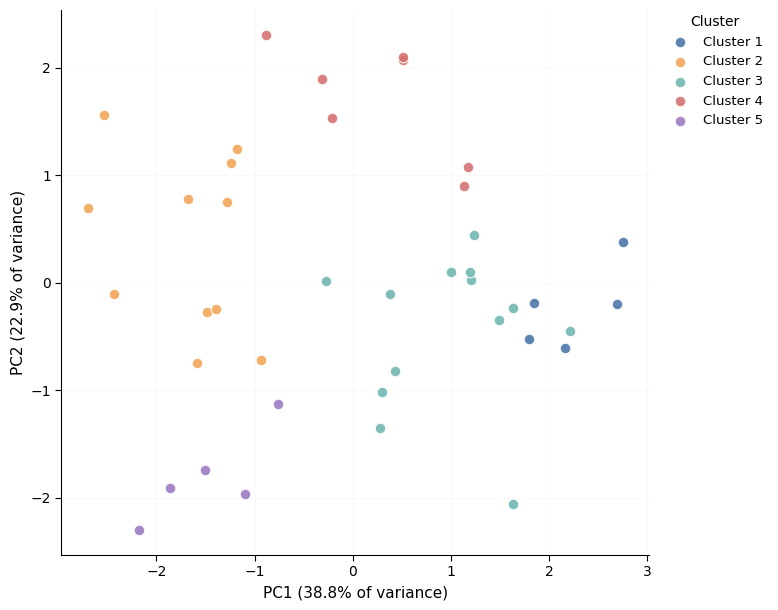

Image saved as: pca_cluster_scatter_pc1_pc2_clean.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Build PCA plotting dataframe
# -----------------------------
pca_plot_df = pd.DataFrame({
    "County": cluster_data["judet"].values,
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "Cluster": cluster_solution["Cluster"].values
})

# -----------------------------
# 2. Explained variance for axis labels
# -----------------------------
pc1_var = pca_variance.loc[0, "Explained variance ratio"] * 100
pc2_var = pca_variance.loc[1, "Explained variance ratio"] * 100

# -----------------------------
# 3. Define calmer color palette
# -----------------------------
cluster_colors = {
    1: "#4C78A8",  # muted blue
    2: "#F2A65A",  # soft orange
    3: "#72B7B2",  # muted teal
    4: "#D67272",  # soft red
    5: "#9D7BC3"   # muted purple
}

# -----------------------------
# 4. Create cleaner academic-style PCA scatterplot
# -----------------------------
fig, ax = plt.subplots(figsize=(9.2, 6.2), facecolor="white")
ax.set_facecolor("white")

for cluster in sorted(pca_plot_df["Cluster"].unique()):
    subset = pca_plot_df[pca_plot_df["Cluster"] == cluster]
    
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        s=58,
        color=cluster_colors.get(cluster, "#4C78A8"),
        alpha=0.9,
        edgecolor="white",
        linewidth=0.8
    )

ax.set_title(
    "County Clusters in PCA Space (PC1 vs PC2)",
    fontsize=13,
    fontweight="bold",
    pad=15
)

# Axis labels
ax.set_xlabel(f"PC1 ({pc1_var:.1f}% of variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% of variance)", fontsize=11)

# No title inside image
ax.set_title("")

# Cleaner spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# Make grid more subtle
ax.grid(True, linestyle="-", linewidth=0.4, alpha=0.12)

# Tick styling
ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)

# Legend outside the plotting area
legend = ax.legend(
    title="Cluster",
    frameon=False,
    fontsize=9.5,
    title_fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0
)

# Keep some room on the right for the legend
plt.tight_layout(rect=[0, 0, 0.86, 1])

# Save figure
output_file = "pca_cluster_scatter_pc1_pc2_clean.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Image saved as: {output_file}")

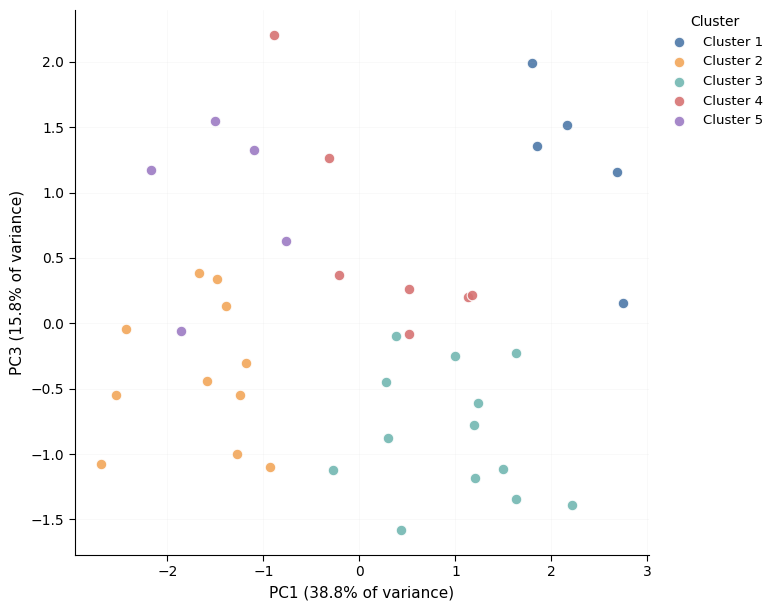

Image saved as: pca_cluster_scatter_pc1_pc3_clean.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Explained variance for axis labels
# -----------------------------
pc1_var = pca_variance.loc[0, "Explained variance ratio"] * 100
pc3_var = pca_variance.loc[2, "Explained variance ratio"] * 100

# -----------------------------
# 2. Calmer color palette
# -----------------------------
cluster_colors = {
    1: "#4C78A8",
    2: "#F2A65A",
    3: "#72B7B2",
    4: "#D67272",
    5: "#9D7BC3"
}

# -----------------------------
# 3. Create cleaner academic-style PCA scatterplot
# -----------------------------
fig, ax = plt.subplots(figsize=(9.2, 6.2), facecolor="white")
ax.set_facecolor("white")

for cluster in sorted(pca_plot_df["Cluster"].unique()):
    subset = pca_plot_df[pca_plot_df["Cluster"] == cluster]
    
    ax.scatter(
        subset["PC1"],
        subset["PC3"],
        label=f"Cluster {cluster}",
        s=58,
        color=cluster_colors.get(cluster, "#4C78A8"),
        alpha=0.9,
        edgecolor="white",
        linewidth=0.8
    )


ax.set_title(
    "County Clusters in PCA Space (PC1 vs PC3)",
    fontsize=13,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(f"PC1 ({pc1_var:.1f}% of variance)", fontsize=11)
ax.set_ylabel(f"PC3 ({pc3_var:.1f}% of variance)", fontsize=11)

ax.set_title("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(True, linestyle="-", linewidth=0.4, alpha=0.12)

ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)

legend = ax.legend(
    title="Cluster",
    frameon=False,
    fontsize=9.5,
    title_fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.86, 1])

output_file = "pca_cluster_scatter_pc1_pc3_clean.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Image saved as: {output_file}")

### 9. Cluster Profiles and Interpretation

In [18]:
#Cluster profiles using original variables

cluster_profiles_final = (
    cluster_solution
    .groupby("Cluster")[final_vars]
    .mean()
    .reset_index()
)

cluster_profiles_final = cluster_profiles_final.rename(columns={
    "rata_emig_15_64": "Average emigration rate, age group 15–64",
    "pondere_ocupati_aff_eurostat": "Average share of employment in agriculture",
    "indice_mecanizare_rezidual": "Average residual mechanization index",
    "crop_yield_index": "Average crop yield index",
    "precipitatii_anuale_mm": "Average annual precipitation",
    "log_total_cultivated_area": "Average log total cultivated area"
})

display(cluster_profiles_final.round(3))

,Cluster,"Average emigration rate, age group 15–64",Average share of employment in agriculture,Average residual mechanization index,Average crop yield index,Average annual precipitation,Average log total cultivated area
0,1,1.970,13.561,0.504,-0.180,966.315,10.370
1,2,1.227,41.966,-0.159,0.251,643.536,12.562
2,3,0.936,25.609,-0.284,-0.265,829.575,11.041
3,4,1.347,16.335,0.970,0.433,812.341,11.951
4,5,2.298,39.284,-0.772,-0.340,590.898,12.151


#### Cluster 1 — Low-Agriculture-Profile Counties with High Migration

- Lowest average share of employment in agriculture, forestry and fishing (13.561)
- Positive residual mechanization index (0.504), the second highest among the five clusters
- Relatively high working-age emigration rate (1.970), the second highest
- Below-average crop productivity index (-0.180)
- Lowest average cultivated area
- Highest average annual precipitation (966.315 mm)

This cluster is characterized by limited agricultural dependence and relatively small cultivated areas. Despite comparatively high emigration, residual mechanization is above average, while crop productivity remains below average.


#### Cluster 2 — Large Agricultural Counties with High Labour Dependence

- Highest average share of employment in agriculture, forestry and fishing (41.966)
- Highest average cultivated area
- Slightly negative residual mechanization index (-0.159)
- Above-average crop productivity index (0.251)
- Intermediate working-age emigration rate
- Relatively low average annual precipitation (643.536 mm)

This cluster represents counties with a strong agricultural profile, characterized by large cultivated areas and high agricultural employment. Productivity is above average despite slightly below-average residual mechanization.


#### Cluster 3 — Low-Migration Counties with Below-Average Productivity

- Lowest working-age emigration rate (0.936)
- Intermediate share of employment in agriculture, forestry and fishing (25.609)
- Below-average crop productivity index (-0.265)
- Relatively small cultivated area
- Relatively high average annual precipitation (829.575 mm)

This cluster shows an intermediate agricultural profile, distinguished primarily by low emigration and below-average crop productivity.


#### Cluster 4 — Highly Mechanized and Productive Agricultural Counties

- Highest residual mechanization index (0.970)
- Highest average crop productivity index (0.433)
- Relatively low share of employment in agriculture, forestry and fishing (16.335)
- Substantial cultivated area
- Relatively high average annual precipitation (812.341 mm)

This cluster combines high residual mechanization with the highest average crop productivity and relatively low agricultural labour dependence.


#### Cluster 5 — High-Migration, Labour-Dependent Agricultural Counties with Low Mechanization

- Highest working-age emigration rate (2.298)
- Second-highest share of employment in agriculture, forestry and fishing (39.284)
- Lowest residual mechanization index (-0.772)
- Lowest average crop productivity index (-0.340)
- Lowest average annual precipitation (590.898 mm)
- Second-largest cultivated area

This cluster represents a comparatively vulnerable agricultural profile, combining high emigration and strong agricultural labour dependence with low residual mechanization and below-average crop productivity.

The five clusters were labelled based on their average values on the original variables, rather than on the PCA scores directly. The labels therefore capture substantive county profiles in terms of migration pressure, agricultural labour dependence, mechanization and productivity. A key distinction emerges between high-emigration counties with low agricultural exposure and high-emigration counties that remain strongly dependent on agricultural labour and display weak mechanization and productivity.

### 10. Cluster Profile Heatmap

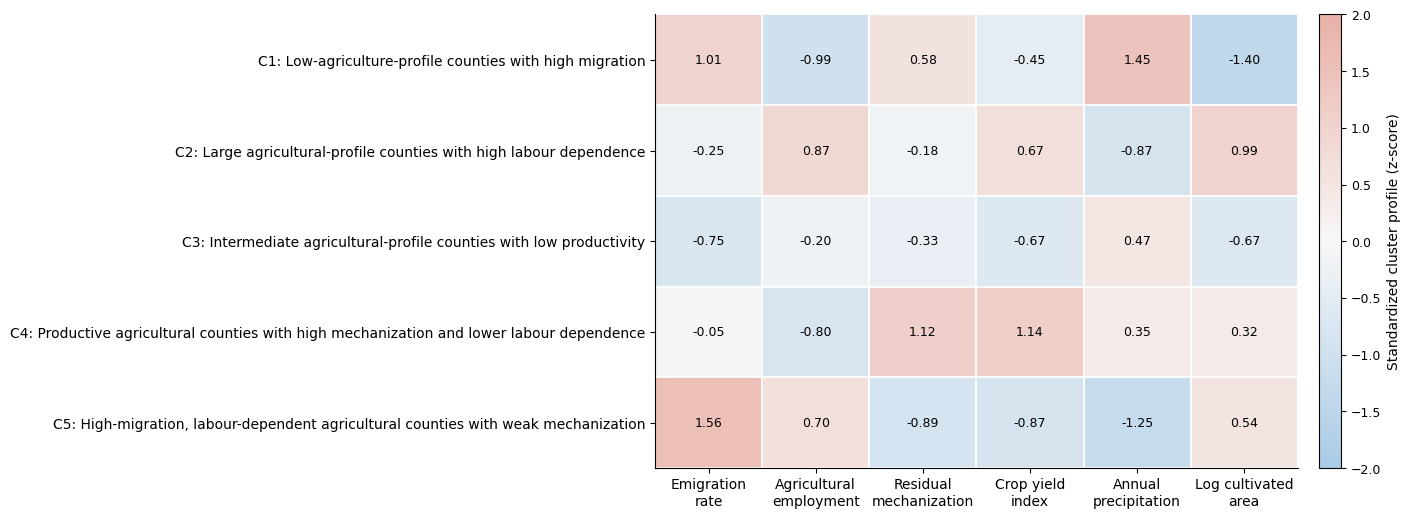

Image saved as: cluster_profile_heatmap_full_labels.png


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# 1. Variables shown in heatmap
# -----------------------------
heatmap_vars = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_rezidual",
    "crop_yield_index",
    "precipitatii_anuale_mm",
    "log_total_cultivated_area"
]

heatmap_vars = [v for v in heatmap_vars if v in cluster_solution.columns]

# -----------------------------
# 2. Compute cluster means
# -----------------------------
cluster_profiles_heatmap = (
    cluster_solution
    .groupby("Cluster")[heatmap_vars]
    .mean()
)

# -----------------------------
# 3. Standardize relative to all counties
# -----------------------------
overall_means = cluster_data[heatmap_vars].mean()
overall_stds = cluster_data[heatmap_vars].std(ddof=1)

cluster_profiles_z = (cluster_profiles_heatmap - overall_means) / overall_stds

# -----------------------------
# 4. Full cluster labels
# -----------------------------
cluster_labels_final = {
    1: "C1: Low-agriculture-profile counties with high migration",
    2: "C2: Large agricultural-profile counties with high labour dependence",
    3: "C3: Intermediate agricultural-profile counties with low productivity",
    4: "C4: Productive agricultural counties with high mechanization and lower labour dependence",
    5: "C5: High-migration, labour-dependent agricultural counties with weak mechanization"
}

cluster_profiles_z.index = [
    cluster_labels_final.get(c, f"Cluster {c}")
    for c in cluster_profiles_z.index
]

# -----------------------------
# 5. Shorter variable labels
# -----------------------------
variable_labels = {
    "rata_emig_15_64": "Emigration\nrate",
    "pondere_ocupati_aff_eurostat": "Agricultural\nemployment",
    "indice_mecanizare_rezidual": "Residual\nmechanization",
    "crop_yield_index": "Crop yield\nindex",
    "precipitatii_anuale_mm": "Annual\nprecipitation",
    "log_total_cultivated_area": "Log cultivated\narea"
}

cluster_profiles_z = cluster_profiles_z.rename(columns=variable_labels)

# Values to annotate
annot_values = cluster_profiles_z.round(2)

# -----------------------------
# 6. Pale diverging colormap
# -----------------------------
pale_cmap = LinearSegmentedColormap.from_list(
    "pale_diverging",
    ["#A9CBE6", "#F7F7F7", "#E9B0A6"],
    N=256
)

# -----------------------------
# 7. Plot heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(12.8, 5.6), facecolor="white")
ax.set_facecolor("white")

im = ax.imshow(
    cluster_profiles_z.values,
    cmap=pale_cmap,
    aspect="auto",
    vmin=-2,
    vmax=2
)

# Axis ticks
ax.set_xticks(np.arange(cluster_profiles_z.shape[1]))
ax.set_yticks(np.arange(cluster_profiles_z.shape[0]))

ax.set_xticklabels(cluster_profiles_z.columns, fontsize=10)
ax.set_yticklabels(cluster_profiles_z.index, fontsize=10)

# X labels
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Add annotations inside cells
for i in range(cluster_profiles_z.shape[0]):
    for j in range(cluster_profiles_z.shape[1]):
        value = annot_values.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

# White borders between cells
ax.set_xticks(np.arange(-0.5, cluster_profiles_z.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, cluster_profiles_z.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.3)
ax.tick_params(which="minor", bottom=False, left=False)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Standardized cluster profile (z-score)", fontsize=10)

# No title
ax.set_title("")

# Important: leave more room on the left for long cluster names
plt.subplots_adjust(left=0.38, right=0.92, bottom=0.16, top=0.97)

output_file = "cluster_profile_heatmap_full_labels.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Image saved as: {output_file}")

### 10. Cluster Profile Heatmap

In [20]:
import geopandas as gpd

gdf = gpd.read_file("../../data/spatial/Judete.shp")

print(gdf.columns)
display(gdf.head())

Index(['Judet', 'cod', 'geometry'], dtype='object')


,Judet,cod,geometry
0,AB,1,"POLYGON ((329798.694 566100.697, 329727.833 56..."
1,AG,2,"POLYGON ((482301.1 456853.24, 482330 456850.92..."
2,AR,3,"POLYGON ((260963.488 580319.733, 260991.53 580..."
3,B,4,"POLYGON ((596590.924 323677.844, 596637.186 32..."
4,BC,5,"POLYGON ((645341.844 593710.876, 645365.732 59..."


County Name Harmonization

County names in the spatial dataset use abbreviated or differently formatted labels. A mapping dictionary is therefore used to harmonize county names with those in the analytical dataset before merging the cluster results with the geographic data.

In [28]:
gdf = gdf[gdf["Judet"] != "B"].copy()
gdf.head(10)

,Judet,cod,geometry
0,AB,1,"POLYGON ((329798.694 566100.697, 329727.833 56..."
1,AG,2,"POLYGON ((482301.1 456853.24, 482330 456850.92..."
2,AR,3,"POLYGON ((260963.488 580319.733, 260991.53 580..."
4,BC,5,"POLYGON ((645341.844 593710.876, 645365.732 59..."
5,BH,6,"POLYGON ((288495.4 681623.68, 288530.73 681575..."
6,BN,7,"POLYGON ((454564.75 678457.58, 454601.95 67844..."
7,BR,8,"POLYGON ((708296.157 446710.624, 708232.202 44..."
8,BT,9,"POLYGON ((627688.67 751356.23, 627755.61 75128..."
9,BV,10,"POLYGON ((520322.792 521223.062, 520331.754 52..."
10,BZ,11,"POLYGON ((608763.162 478616.205, 608825.658 47..."


Unmapped counties:


,judet,Cluster,county_code


Unmatched map polygons:


,Judet,cod


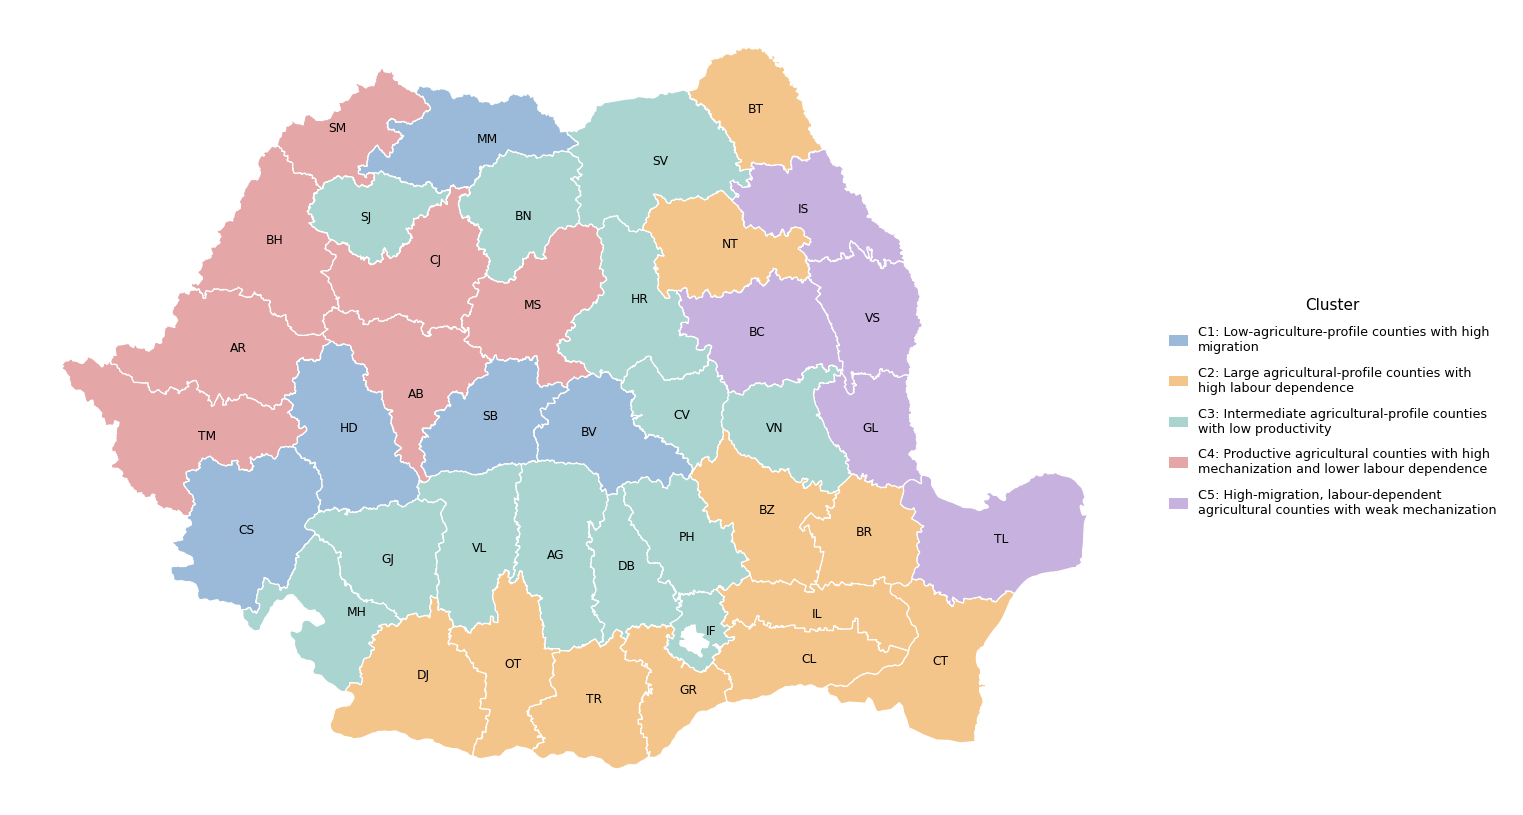

Image saved as: romania_counties_by_cluster_codes_large_compact_legend.png


In [21]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import textwrap

# -----------------------------
# 1. County name -> county code dictionary
# -----------------------------
county_code_map = {
    "Alba": "AB",
    "Arad": "AR",
    "Arges": "AG",
    "Bacau": "BC",
    "Bihor": "BH",
    "Bistrita-Nasaud": "BN",
    "Botosani": "BT",
    "Brasov": "BV",
    "Braila": "BR",
    "Buzau": "BZ",
    "Caras-Severin": "CS",
    "Calarasi": "CL",
    "Cluj": "CJ",
    "Constanta": "CT",
    "Covasna": "CV",
    "Dambovita": "DB",
    "Dolj": "DJ",
    "Galati": "GL",
    "Giurgiu": "GR",
    "Gorj": "GJ",
    "Harghita": "HR",
    "Hunedoara": "HD",
    "Ialomita": "IL",
    "Iasi": "IS",
    "Ilfov": "IF",
    "Maramures": "MM",
    "Mehedinti": "MH",
    "Mures": "MS",
    "Neamt": "NT",
    "Olt": "OT",
    "Prahova": "PH",
    "Satu Mare": "SM",
    "Salaj": "SJ",
    "Sibiu": "SB",
    "Suceava": "SV",
    "Teleorman": "TR",
    "Timis": "TM",
    "Tulcea": "TL",
    "Vaslui": "VS",
    "Valcea": "VL",
    "Vrancea": "VN"
}

# -----------------------------
# 2. Build county-cluster table
# -----------------------------
county_clusters = cluster_solution[["judet", "Cluster"]].drop_duplicates().copy()
county_clusters["county_code"] = county_clusters["judet"].map(county_code_map)

unmapped = county_clusters[county_clusters["county_code"].isna()]
print("Unmapped counties:")
display(unmapped)

# -----------------------------
# 3. Merge clusters with shapefile
# -----------------------------
map_df = gdf.merge(
    county_clusters,
    left_on="Judet",
    right_on="county_code",
    how="left"
)

# Exclude Bucharest 
map_df = map_df[map_df["Judet"] != "B"].copy()

unmatched_map = map_df[map_df["Cluster"].isna()][["Judet", "cod"]]
print("Unmatched map polygons:")
display(unmatched_map)

# -----------------------------
# 4. Cluster labels
# -----------------------------
cluster_labels_final = {
    1: "C1: Low-agriculture-profile counties with high migration",
    2: "C2: Large agricultural-profile counties with high labour dependence",
    3: "C3: Intermediate agricultural-profile counties with low productivity",
    4: "C4: Productive agricultural counties with high mechanization and lower labour dependence",
    5: "C5: High-migration, labour-dependent agricultural counties with weak mechanization"
}


cluster_labels_wrapped = {
    c: textwrap.fill(label, width=48)
    for c, label in cluster_labels_final.items()
}

# -----------------------------
# 5. Pale color palette
# -----------------------------
cluster_colors = {
    1: "#9BBAD9",  # pale blue
    2: "#F3C58B",  # pale orange
    3: "#A9D4CF",  # pale teal
    4: "#E4A6A6",  # pale rose
    5: "#C7B2DF"   # pale purple
}

map_df["color"] = map_df["Cluster"].map(cluster_colors)

# -----------------------------
# 6. Create figure with manual layout
# -----------------------------
fig = plt.figure(figsize=(15.5, 9), facecolor="white")

# Bigger map area
ax_map = fig.add_axes([0.02, 0.04, 0.73, 0.92])

# Narrower legend area
ax_leg = fig.add_axes([0.76, 0.18, 0.23, 0.64])
ax_leg.axis("off")

# -----------------------------
# 7. Plot map
# -----------------------------
map_df.plot(
    color=map_df["color"],
    edgecolor="white",
    linewidth=0.9,
    ax=ax_map
)

# Add county abbreviations
for _, row in map_df.iterrows():
    if row.geometry is not None and pd.notna(row["Judet"]):
        point = row.geometry.representative_point()
        ax_map.text(
            point.x,
            point.y,
            row["Judet"],
            fontsize=8.8,
            ha="center",
            va="center",
            color="black"
        )

ax_map.set_axis_off()

# -----------------------------
# 8. Legend in separate right-side area
# -----------------------------
legend_handles = [
    Patch(
        facecolor=cluster_colors[c],
        edgecolor="none",
        label=cluster_labels_wrapped[c]
    )
    for c in sorted(cluster_colors.keys())
]

ax_leg.legend(
    handles=legend_handles,
    loc="center left",
    frameon=False,
    fontsize=9.2,
    title="Cluster",
    title_fontsize=11,
    handlelength=1.5,
    handleheight=0.9,
    labelspacing=1.0
)

# -----------------------------
# 9. Save figure
# -----------------------------
output_file = "romania_counties_by_cluster_codes_large_compact_legend.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Image saved as: {output_file}")

### 12. Alternative Clustering Specifications

To assess the robustness of the clustering structure, several alternative specifications were compared across different variable sets, scaling methods, dimensionality-reduction approaches, clustering algorithms, and numbers of clusters.

In [35]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# -----------------------------
# 1. Define variable sets
# -----------------------------
test_variable_sets = {
    "A_full_theoretical": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index",
        "precipitatii_anuale_mm",
        "log_total_cultivated_area"
    ],
    
    "B_core": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index"
    ],
    
    "C_core_plus_area": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index",
        "log_total_cultivated_area"
    ],
    
    "D_core_plus_precipitation": [
        "rata_emig_15_64",
        "pondere_ocupati_aff_eurostat",
        "indice_mecanizare_rezidual",
        "crop_yield_index",
        "precipitatii_anuale_mm"
    ]
}

# -----------------------------
# 2. Evaluation function
# -----------------------------
def evaluate_labels(X, labels):
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    # avoid invalid / useless solutions
    if len(cluster_sizes) < 2 or cluster_sizes.min() < 2:
        return None
    
    return {
        "Silhouette": silhouette_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Cluster sizes": dict(cluster_sizes)
    }

# -----------------------------
# 3. Test methods
# -----------------------------
results = []

for set_name, vars_list in test_variable_sets.items():
    vars_existing = [v for v in vars_list if v in cluster_data.columns]
    X_raw = cluster_data[vars_existing].copy()
    
    if X_raw.isna().sum().sum() > 0:
        print(f"Skipping {set_name}: missing values present.")
        continue
    
    for scaler_name, scaler in {
        "StandardScaler": StandardScaler(),
        "RobustScaler": RobustScaler()
    }.items():
        
        X_scaled = scaler.fit_transform(X_raw)
        
        # PCA variants
        pca_options = {
            "No PCA": X_scaled
        }
        
        max_pca = min(3, X_scaled.shape[1])
        for n_comp in range(2, max_pca + 1):
            pca = PCA(n_components=n_comp, random_state=42)
            X_pca_temp = pca.fit_transform(X_scaled)
            pca_options[f"PCA_{n_comp}"] = X_pca_temp
        
        for pca_name, X_used in pca_options.items():
            for k in range(2, 7):
                
                models = {
                    "K-means": KMeans(n_clusters=k, random_state=42, n_init=30),
                    "Ward": AgglomerativeClustering(n_clusters=k, linkage="ward"),
                    "GMM": GaussianMixture(n_components=k, random_state=42, covariance_type="full")
                }
                
                # Spectral sometimes works better, but can be unstable with small samples
                if k < len(cluster_data):
                    models["Spectral"] = SpectralClustering(
                        n_clusters=k,
                        random_state=42,
                        affinity="nearest_neighbors",
                        n_neighbors=min(10, len(cluster_data)-1)
                    )
                
                for method_name, model in models.items():
                    try:
                        labels = model.fit_predict(X_used)
                        metrics = evaluate_labels(X_used, labels)
                        
                        if metrics is None:
                            continue
                        
                        results.append({
                            "Variable set": set_name,
                            "Scaler": scaler_name,
                            "Dimensionality": pca_name,
                            "Method": method_name,
                            "k": k,
                            "Silhouette": metrics["Silhouette"],
                            "Calinski-Harabasz": metrics["Calinski-Harabasz"],
                            "Davies-Bouldin": metrics["Davies-Bouldin"],
                            "Cluster sizes": metrics["Cluster sizes"]
                        })
                        
                    except Exception as e:
                        pass

comparison_results = pd.DataFrame(results)

comparison_results["Silhouette"] = comparison_results["Silhouette"].round(3)
comparison_results["Calinski-Harabasz"] = comparison_results["Calinski-Harabasz"].round(3)
comparison_results["Davies-Bouldin"] = comparison_results["Davies-Bouldin"].round(3)

comparison_results = comparison_results.sort_values(
    "Silhouette", 
    ascending=False
).reset_index(drop=True)

display(comparison_results.head(30))

,Variable set,Scaler,Dimensionality,Method,k,Silhouette,Calinski-Harabasz,Davies-Bouldin,Cluster sizes
0,A_full_theoretical,RobustScaler,PCA_2,K-means,3,0.495,47.381,0.667,"{0: 15, 1: 10, 2: 16}"
1,A_full_theoretical,RobustScaler,PCA_2,Spectral,3,0.492,46.545,0.679,"{0: 16, 1: 11, 2: 14}"
2,A_full_theoretical,RobustScaler,PCA_2,Ward,3,0.467,40.099,0.753,"{0: 12, 1: 15, 2: 14}"
3,C_core_plus_area,RobustScaler,PCA_2,K-means,3,0.465,41.297,0.688,"{0: 11, 1: 15, 2: 15}"
4,C_core_plus_area,RobustScaler,PCA_2,Ward,3,0.464,40.652,0.690,"{0: 16, 1: 10, 2: 15}"
5,C_core_plus_area,RobustScaler,PCA_2,GMM,3,0.464,40.652,0.690,"{0: 15, 1: 16, 2: 10}"
6,A_full_theoretical,StandardScaler,PCA_2,K-means,3,0.460,43.925,0.753,"{0: 19, 1: 10, 2: 12}"
7,D_core_plus_precipitation,RobustScaler,PCA_2,GMM,4,0.455,42.619,0.691,"{0: 16, 1: 12, 2: 9, 3: 4}"
8,D_core_plus_precipitation,RobustScaler,PCA_2,GMM,3,0.453,39.019,0.744,"{0: 15, 1: 15, 2: 11}"
9,A_full_theoretical,RobustScaler,PCA_2,K-means,4,0.452,44.387,0.754,"{0: 5, 1: 11, 2: 15, 3: 10}"


### Summary

The cluster analysis identified five exploratory regional profiles based on migration, agricultural employment, mechanization, crop productivity, climatic conditions, and cultivated area.

The results reveal substantial heterogeneity across Romanian counties. In particular, some counties combine high mechanization with relatively high agricultural productivity and lower dependence on agricultural labour, while others are characterized by high emigration, strong agricultural labour dependence, low mechanization, and below-average productivity.

Alternative clustering specifications were evaluated to assess the robustness of the regional structure. Although some alternative solutions achieved higher internal validation scores, the five-cluster solution was retained because it provided a more detailed and substantively interpretable regional typology consistent with the objectives of the analysis.

The clusters should therefore be interpreted as exploratory regional profiles rather than as sharply separated or definitive groups.